In [1]:
# Cell 1 — Import Library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             classification_report, roc_auc_score,
                             roc_curve)
import pickle
import warnings
warnings.filterwarnings('ignore')

Matplotlib is building the font cache; this may take a moment.


In [2]:
# Cell 2 - Load & Eksplorasi Data:**
df = pd.read_csv('diabetes.csv')
print('Shape:' , df.shape)
print('\nStatistik Deskriptif:')
df.describe().round(2)

Shape: (768, 9)

Statistik Deskriptif:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Jumlah nilai 0 (missing): Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


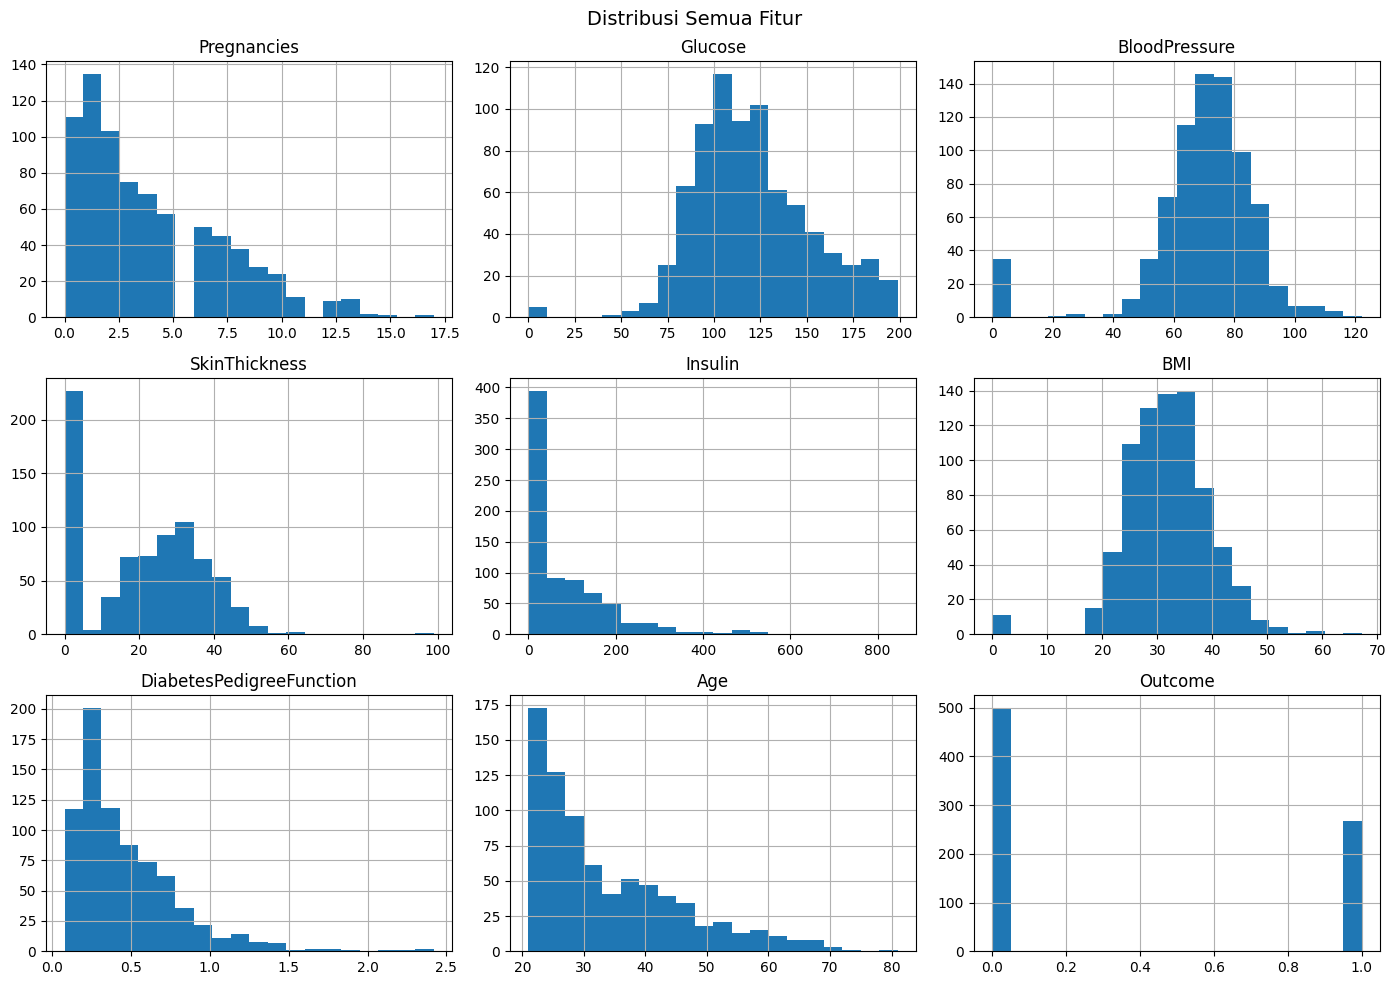

In [4]:
# Cell 3 — Cek Missing Values & Distribusi
# Nilai 0 pada kolom tertentu = missing
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print('Jumlah nilai 0 (missing):',
    (df[cols_with_zero] == 0).sum())

# Visualisasi distribusi
df.hist(bins=20, figsize=(14, 10))
plt.suptitle('Distribusi Semua Fitur', fontsize=14)
plt.tight_layout()
plt.savefig('distribusi.png', dpi=100)
plt.show()

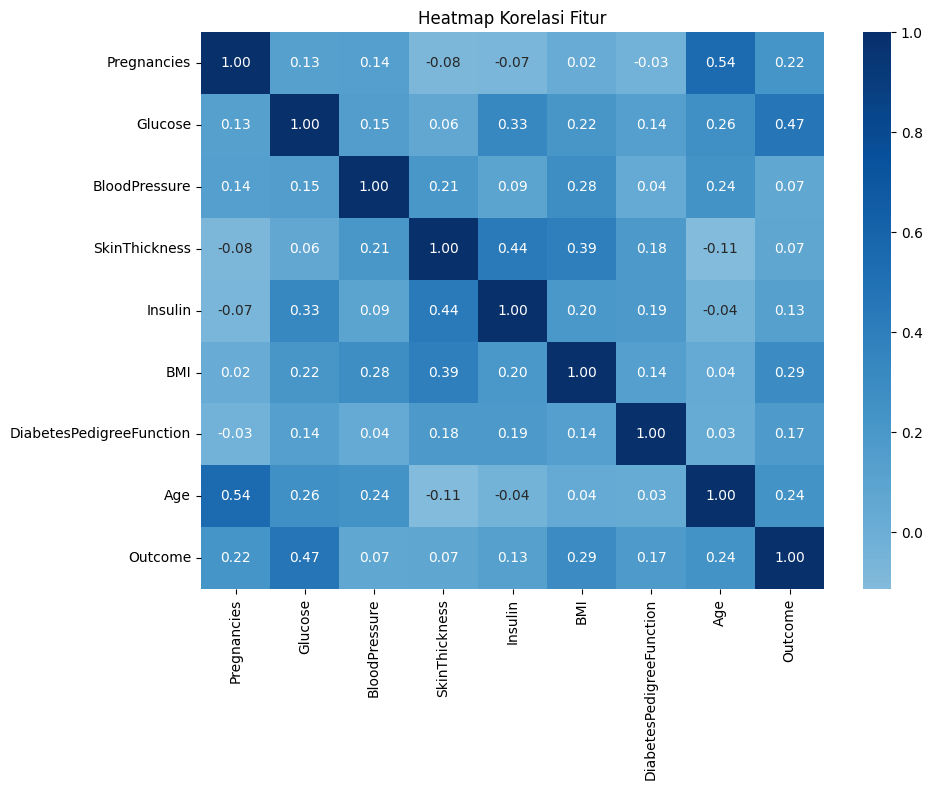

In [5]:
# Cell 4 - Visualisasi Korelasi
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(),annot=True, fmt='.2f',
            cmap='Blues',center=0)
plt.title('Heatmap Korelasi Fitur')
plt.tight_layout()
plt.savefig('korelasi.png', dpi=100)
plt.show()

In [6]:
# Cell 5 — Handle Missing Values
# Ganti 0 dengan median per outcome group
for col in cols_with_zero:
    median_0 = df[df['Outcome']==0][col].median()
    median_1 = df[df['Outcome']==1][col].median()
    df.loc[(df['Outcome']==0) & (df[col]==0), col] = median_0
    df.loc[(df['Outcome']==1) & (df[col]==0), col] = median_1

print('Missing values setelah handling:')
print((df[cols_with_zero] == 0).sum().sum())

Missing values setelah handling:
138


In [7]:
# Cell 6 — Split Fitur & Label
X = df.drop('Outcome', axis=1) # 8 fitur
y = df['Outcome']              # label (0=tidak, 1=diabetes)

# Split train/test (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print(f'Distribusi label train: {y_train.value_counts().to_dict()}')

Train: (614, 8), Test: (154, 8)
Distribusi label train: {0: 400, 1: 214}


In [8]:
# Cell 7 — Normalisasi (StandardScaler / Z-score)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Mean setelah scaling:', X_train_scaled.mean(axis=0).round(2))
print('Std setelah scaling:', X_train_scaled.std(axis=0).round(2))

Mean setelah scaling: [-0. -0.  0. -0.  0.  0. -0. -0.]
Std setelah scaling: [1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
# Cell 8 — Training Logistic Regression
model = LogisticRegression(
    C=1.0,           # Regularization strength
    max_iter=1000,   # Iterasi maksimum
    random_state=42
)
model.fit(X_train_scaled, y_train)

# Prediksi
y_pred = model.predict(X_test_scaled)
y_pred_prob = model.predict_proba(X_test_scaled)[:, 1]

=== HASIL EVALUASI MODEL ===
Accuracy : 0.7273
ROC-AUC  : 0.8209

Classification Report:
                precision    recall  f1-score   support

Tidak Diabetes       0.76      0.85      0.80       100
      Diabetes       0.64      0.50      0.56        54

      accuracy                           0.73       154
     macro avg       0.70      0.68      0.68       154
  weighted avg       0.72      0.73      0.72       154



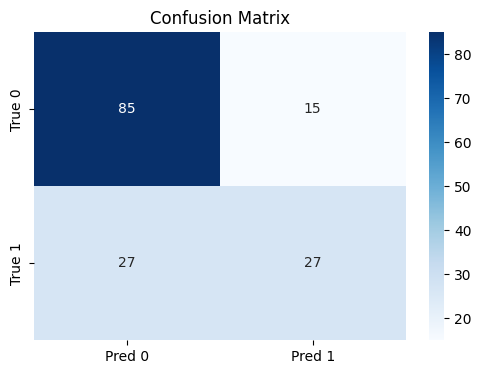

In [10]:
# Cell 9 — Evaluasi Metrik
print('=== HASIL EVALUASI MODEL ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, y_pred_prob):.4f}')
print()
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Tidak Diabetes', 'Diabetes']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4)) # Ukuran disesuaikan agar rapi
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred 0', 'Pred 1'],
            yticklabels=['True 0', 'True 1'])
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=100)
plt.show()

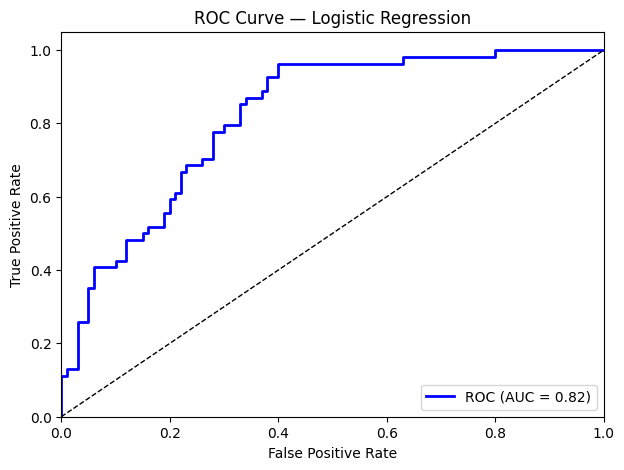

In [11]:
# Cell 10 — Kurva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='blue', lw=2,
         label=f'ROC (AUC = {roc_auc_score(y_test, y_pred_prob):.2f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Logistic Regression')
plt.legend(loc="lower right")
plt.savefig('roc_curve.png', dpi=100)
plt.show()

                   Fitur  Koefisien
                 Glucose   1.310410
                     BMI   0.555193
           SkinThickness   0.397582
             Pregnancies   0.361065
DiabetesPedigreeFunction   0.259835
                     Age   0.111436
           BloodPressure  -0.056507
                 Insulin  -0.400531


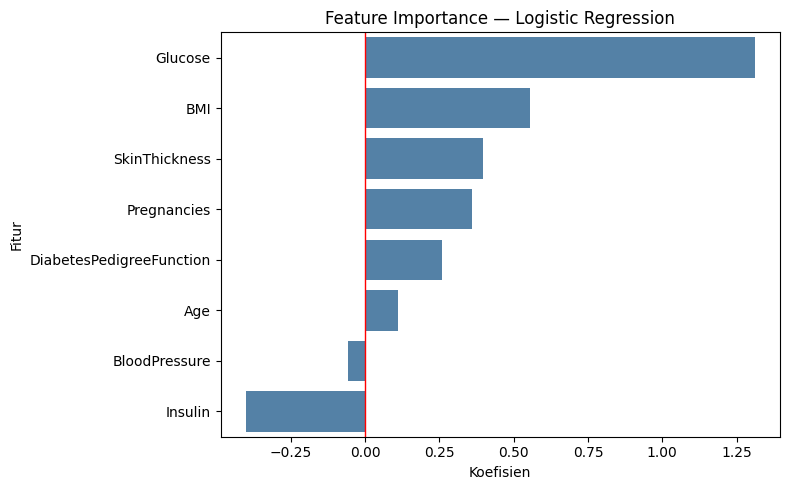

In [12]:
# Cell 11 — Tampilkan Bobot (Koefisien) Model
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_[0]
}).sort_values('Koefisien', ascending=False)
print(coef_df.to_string(index=False))

# Visualisasi
plt.figure(figsize=(8, 5))
sns.barplot(x='Koefisien', y='Fitur', data=coef_df, color='steelblue')
plt.title('Feature Importance — Logistic Regression')
plt.axvline(0, color='red', lw=1)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=100)
plt.show()

In [14]:
# Cell 12 — Simpan Model & Scaler
import pickle

with open('../backend/model.pkl', 'wb') as f:
    pickle.dump(model, f)

with open('../backend/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Model dan scaler berhasil disimpan!")
print(f"Intercept : {model.intercept_[0]:.4f}")
print(f"Koefisien : {model.coef_[0]}")

✅ Model dan scaler berhasil disimpan!
Intercept : -0.9039
Koefisien : [ 0.36106514  1.31041036 -0.0565074   0.39758198 -0.40053092  0.55519276
  0.25983549  0.11143582]
